# Notebook 2: From Spin Echo to Projection and Image

## Section I — 1D Spin Echo Projection

In the previous notebook, we built and calibrated the RF spin echo.

Now we take the next step:

> Add one readout gradient to the RF spin echo so that the measured echo contains spatial information along one direction.

This gives us a **1D spin echo projection**.

The progression is:

```text
RF spin echo → add readout gradient → 1D projection

| Block  | Goal                                                                |
| ------ | ------------------------------------------------------------------- |
| Learn  | Understand how one gradient turns an echo into a projection         |
| Design | Choose FOV, resolution, ADC duration, and readout gradient          |
| Build  | Create a 1D spin echo projection sequence                           |
| Scan   | Export the sequence and prepare for first 1D projection acquisition |



## Learn: What is a 1D projection?

A spin echo without gradients gives us a signal, but not spatial information.

To get spatial information, we apply a magnetic field gradient during readout.

If we apply a readout gradient along x, spins at different x-positions precess at different frequencies.  
The received signal then contains information about the object along x.

For a 1D projection:

- RF pulses create the spin echo.
- One readout gradient encodes position along one direction.
- ADC samples the echo while the readout gradient is on.
- Fourier transform converts the signal into a 1D projection.

For this section, we still do **not** use phase encoding.

That comes in Section II.

## Design: Low-field scanner and 1D projection parameters

We tailor the sequence to the DELTA DIY MRI low-field scanner and the ex vivo sheep brain target.

| Parameter | Starting value | Notes |
|---|---:|---|
| Main field strength | 0.2516 T | DELTA DIY MRI scanner |
| Larmor frequency | ~10.713 MHz | To be replaced by measured f0 |
| Object | Ex vivo sheep brain | Initial biological target |
| Sequence | Spin echo projection | 90°–180° + readout gradient |
| Readout direction | x | Editable |
| FOV | 160 mm | Adjustable for sheep brain / phantom |
| Readout samples | 256 | Starting value |
| ADC duration | 8 ms | Starting value |
| TE | 40 ms | Should match RF SE baseline |
| TR | 1000 ms | Conservative first setting |
| 90° pulse width | from RF calibration | From Notebook 1 |
| 180° pulse width | ~2 × 90° pulse width | Initial assumption |

In [1]:
# Section I setup

import numpy as np
import matplotlib.pyplot as plt

B0_T = 0.2516
gamma_hz_per_t = 42.576e6
f0_hz = gamma_hz_per_t * B0_T

print("DELTA DIY MRI 1D Spin Echo Projection")
print(f"B0 field strength   : {B0_T:.4f} T")
print(f"Larmor frequency    : {f0_hz/1e6:.3f} MHz")
print("Target object       : ex vivo sheep brain")

DELTA DIY MRI 1D Spin Echo Projection
B0 field strength   : 0.2516 T
Larmor frequency    : 10.712 MHz
Target object       : ex vivo sheep brain


In [2]:
# Sequence design parameters

TE = 10e-3
TR = 1000e-3

# These should come from Notebook 1 after RF pulse-width calibration.
rf90_duration = 150e-6
rf180_duration = 2 * rf90_duration

# 1D readout parameters
fov_m = 0.064          # 70 mm
nx = 64
adc_duration = 8e-3

# Derived values
delta_x_m = fov_m / nx
k_width = nx / fov_m  # cycles/m

print("1D projection design")
print(f"TE                  : {TE*1e3:.1f} ms")
print(f"TR                  : {TR*1e3:.1f} ms")
print(f"FOV                 : {fov_m*1e3:.1f} mm")
print(f"Readout samples     : {nx}")
print(f"Nominal resolution  : {delta_x_m*1e3:.2f} mm")
print(f"ADC duration        : {adc_duration*1e3:.1f} ms")
print(f"k-space width       : {k_width:.1f} cycles/m")
print(f"90° pulse width     : {rf90_duration*1e6:.1f} µs")
print(f"180° pulse width    : {rf180_duration*1e6:.1f} µs")

1D projection design
TE                  : 10.0 ms
TR                  : 1000.0 ms
FOV                 : 64.0 mm
Readout samples     : 64
Nominal resolution  : 1.00 mm
ADC duration        : 8.0 ms
k-space width       : 1000.0 cycles/m
90° pulse width     : 150.0 µs
180° pulse width    : 300.0 µs


## Learn by simulation: A simple 1D sheep-brain-like projection

Before building the sequence, we simulate the idea of a projection.
It is a simple intuition-building model:

1. Create a 1D object profile.
2. Simulate the k-space signal as the Fourier transform of that object.
3. Reconstruct the projection using an inverse Fourier transform.

This helps us see what the readout gradient and ADC are trying to measure.

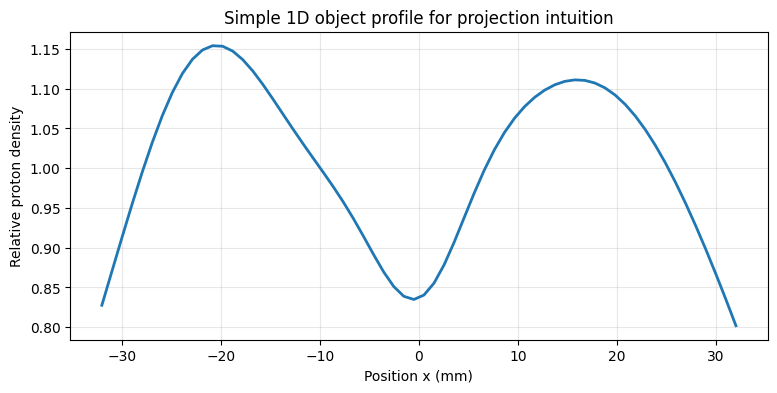

In [3]:
# Create a simple 1D object profile

x = np.linspace(-fov_m / 2, fov_m / 2, nx)

# A simple "ex vivo sheep-brain-like" 1D profile:
# broad tissue region + internal structure + lower-intensity edges
rho = (
    0.95 * np.exp(-(x / 0.045) ** 4)
    + 0.25 * np.exp(-((x + 0.022) / 0.010) ** 2)
    + 0.18 * np.exp(-((x - 0.018) / 0.014) ** 2)
    - 0.15 * np.exp(-((x) / 0.006) ** 2)
)

rho = np.clip(rho, 0, None)

plt.figure(figsize=(9, 4))
plt.plot(x * 1e3, rho, linewidth=2)
plt.xlabel("Position x (mm)")
plt.ylabel("Relative proton density")
plt.title("Simple 1D object profile for projection intuition")
plt.grid(True, alpha=0.3)
plt.show()

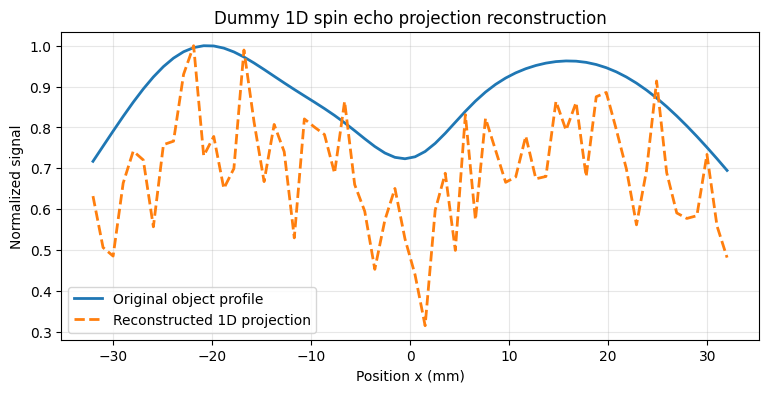

In [4]:
# Simulate 1D k-space signal and reconstruction

# Forward model: signal sampled across k-space
signal_k = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(rho)))

# Add small dummy complex noise
rng = np.random.default_rng(5)
noise_level = 0.02 * np.max(np.abs(signal_k))
signal_k_noisy = signal_k + noise_level * (
    rng.normal(size=signal_k.shape) + 1j * rng.normal(size=signal_k.shape)
)

# Reconstruct projection
rho_recon = np.abs(np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(signal_k_noisy))))
rho_recon = rho_recon / np.max(rho_recon)

rho_display = rho / np.max(rho)

plt.figure(figsize=(9, 4))
plt.plot(x * 1e3, rho_display, linewidth=2, label="Original object profile")
plt.plot(x * 1e3, rho_recon, linewidth=2, linestyle="--", label="Reconstructed 1D projection")
plt.xlabel("Position x (mm)")
plt.ylabel("Normalized signal")
plt.title("Dummy 1D spin echo projection reconstruction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

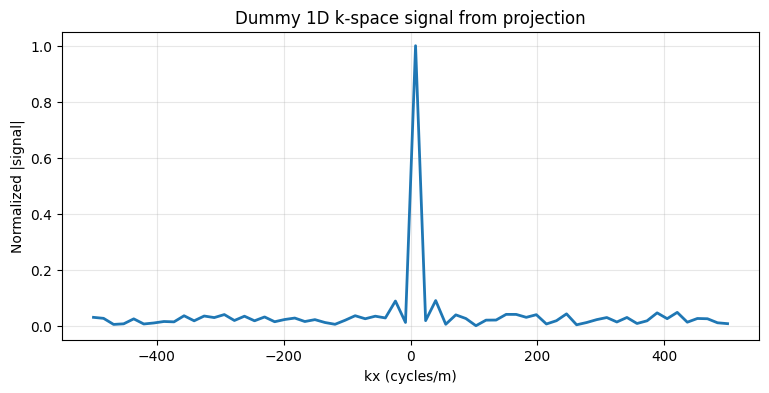

In [5]:
# Show k-space magnitude

kx = np.linspace(-k_width / 2, k_width / 2, nx)

plt.figure(figsize=(9, 4))
plt.plot(kx, np.abs(signal_k_noisy) / np.max(np.abs(signal_k_noisy)), linewidth=2)
plt.xlabel("kx (cycles/m)")
plt.ylabel("Normalized |signal|")
plt.title("Dummy 1D k-space signal from projection")
plt.grid(True, alpha=0.3)
plt.show()

## Design checkpoint

The dummy simulation gives us the imaging logic:

```text
Object along x → readout gradient samples kx → inverse FFT gives 1D projection
The live scanner sequence should therefore:

1. Use the calibrated RF spin echo.
2. Add one readout gradient.
3. Center ADC around the expected echo.
4. Save raw data.
5. Reconstruct a 1D projection using FFT.


## Build: Create the 1D spin echo projection sequence in PyPulseq

This sequence is the RF spin echo sequence plus one readout gradient.

There is still no phase encoding.

The readout gradient is active during ADC, so each ADC sample corresponds to one k-space location along kx.

In [6]:
# Import PyPulseq with compatibility patch if needed

import numpy as np

# Temporary compatibility patch for old PyPulseq versions with newer NumPy.
# For the workshop environment, prefer NumPy 1.23.5 + PyPulseq 1.4.0.
if not hasattr(np, "float"):
    np.float = float

import pypulseq as pp

print("PyPulseq imported successfully.")
print("PyPulseq path:", pp.__file__)

/home/jonathanmartin/anaconda3/envs/adelpha/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyPulseq imported successfully.
PyPulseq path: /home/jonathanmartin/anaconda3/envs/adelpha/lib/python3.11/site-packages/pypulseq/__init__.py


In [7]:
# Define scanner limits
# Placeholder values: replace with measured/approved DELTA DIY MRI scanner limits.

system = pp.Opts(
    max_grad=10,
    grad_unit="mT/m",
    max_slew=50,
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
)

seq = pp.Sequence(system)

BLOCK_RASTER_TIME = 10e-6  # 10 µs

def round_to_raster(t, raster=BLOCK_RASTER_TIME):
    """Round time in seconds to nearest raster point."""
    t_rounded = round(t / raster) * raster
    if t_rounded < 0:
        raise ValueError(f"Negative delay after rounding: {t_rounded*1e6:.1f} µs")
    return t_rounded

print("Sequence object created.")

Sequence object created.


In [8]:
# Create RF pulses

rf90 = pp.make_block_pulse(
    flip_angle=np.pi / 2,
    duration=rf90_duration,
    system=system
)

rf180 = pp.make_block_pulse(
    flip_angle=np.pi,
    duration=rf180_duration,
    system=system
)

print("RF pulses created.")

RF pulses created.


In [9]:
# Create readout gradient and ADC

# For a simple readout, the flat_area is the k-space width in cycles/m.
# This may need adjustment depending on the exact PyPulseq version and scanner interpreter.
gx = pp.make_trapezoid(
    channel="x",
    flat_area=k_width,
    flat_time=adc_duration,
    system=system
)

gx_pre = pp.make_trapezoid(
    channel="x",
    area=gx.area / 2,   
    duration=2e-3,       # 2 ms pre-phasing gradient
    system=system
)


adc = pp.make_adc(
    num_samples=nx,
    duration=adc_duration,
    delay=0,
    system=system
)

print("Readout gradient and ADC created.")
print(f"Readout direction : x")
print(f"FOV               : {fov_m*1e3:.1f} mm")
print(f"Samples           : {nx}")

Readout gradient and ADC created.
Readout direction : x
FOV               : 64.0 mm
Samples           : 64


In [10]:
# Build 1D spin echo projection sequence

# 90° pulse
seq.add_block(rf90)

seq.add_block(gx_pre)  # Pre-phasing gradient

# Delay from end of 90° pulse to center of 180° pulse

delay_to_180 = round_to_raster(
    TE / 2 - rf90_duration / 2 - rf180_duration / 2 - pp.calc_duration(gx_pre)
)

if delay_to_180 < 0:
    raise ValueError("TE is too short for the selected RF pulse durations.")

seq.add_block(pp.make_delay(delay_to_180))

# 180° pulse
seq.add_block(rf180)

# Delay from end of 180° pulse to start of readout,
# with readout centered at TE.
delay_to_readout = round_to_raster(TE / 2 - rf180_duration / 2 - adc_duration / 2)
if delay_to_readout < 0:
    raise ValueError("TE is too short for the selected RF and ADC durations.")

seq.add_block(pp.make_delay(delay_to_readout))

# Readout gradient and ADC
seq.add_block(gx, adc)

# TR delay
used_time = (
    rf90_duration
    + pp.calc_duration(gx_pre)
    + delay_to_180
    + rf180_duration
    + delay_to_readout
    + adc_duration
)

delay_to_TR = round_to_raster(TR - used_time)
if delay_to_TR < 0:
    raise ValueError(
        f"TR is too short by {-delay_to_TR*1e3:.2f} ms. "
        "Increase TR or shorten the sequence."
    )

seq.add_block(pp.make_delay(delay_to_TR))

print("1D spin echo projection sequence constructed.")
print(f"Used time before TR delay : {used_time*1e3:.2f} ms")
print(f"Final TR delay            : {delay_to_TR*1e3:.2f} ms")

1D spin echo projection sequence constructed.
Used time before TR delay : 14.07 ms
Final TR delay            : 985.93 ms


## Inspect: Plot the sequence

The plot should show:

1. A 90° RF pulse.
2. A 180° RF pulse at TE/2.
3. A readout gradient during ADC.
4. The ADC window centered near TE.

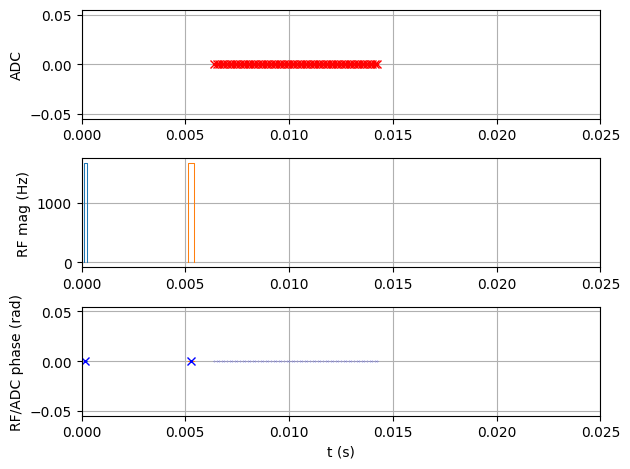

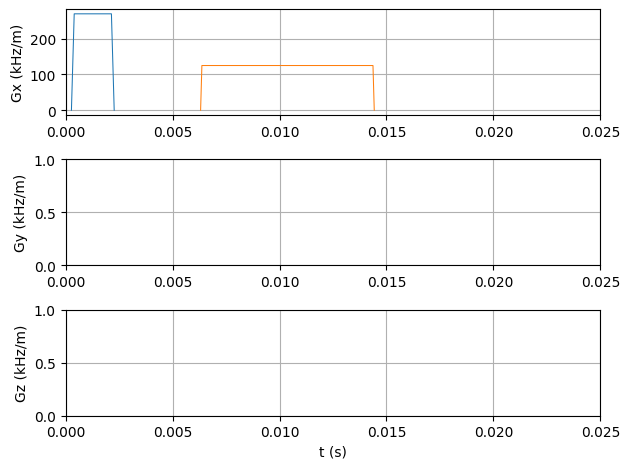

In [11]:
seq.plot(time_range=(0, min(TR, 0.025)))

## Validate and export

Before sending the sequence to the scanner, check timing and export the `.seq` file.

In [12]:
ok, error_report = seq.check_timing()

if ok:
    print("PASS: Sequence timing check passed.")
else:
    print("WARNING: Sequence timing check failed.")
    print(error_report)

PASS: Sequence timing check passed.


In [13]:
out_file = "se_1d_projection_02516T.seq"
seq.write(out_file)

print(f"Saved sequence file: {out_file}")

Saved sequence file: se_1d_projection_02516T.seq


## Scan: Day 1 1D projection checklist

Before running the 1D projection sequence on the scanner:

- [ ] Confirm measured f0
- [ ] Confirm calibrated 90° pulse width
- [ ] Confirm calibrated or estimated 180° pulse width
- [ ] Confirm readout gradient direction
- [ ] Confirm FOV and ADC settings
- [ ] Confirm receiver gain
- [ ] Confirm raw data save location
- [ ] Save sequence file, raw data, and console log
- [ ] Record TE, TR, FOV, samples, ADC duration, and readout direction

Expected result:

> A 1D projection of the ex vivo sheep brain or phantom along the readout direction.

## Transition to Section II

Section I used one gradient to collect a 1D projection.

Section II will now add the missing ingredient:

> Repeat the spin echo readout for multiple phase-encoding values.

That turns the sequence from:

```text
1D projection: RF + readout gradient
into:
2D image: RF + phase encoding + readout gradient
One gradient produces a projection; adding phase encoding later produces an image**. 

| Block    | Goal                                                               |
| -------- | ------------------------------------------------------------------ |
| Learn    | Understand phase encoding and k-space filling                      |
| Design   | Choose FOV, matrix size, TE/TR, readout, and phase encodes         |
| Build    | Create a 2D spin echo sequence                                     |
| Simulate | Use MRZero or a fallback simulator to visualize a brain-like image |
| Scan     | Export the sequence and prepare for the first 2D SE acquisition    |


### Learn: What changes from 1D SE to 2D SE?

A 1D spin echo projection uses:

- RF excitation
- RF refocusing
- one readout gradient
- ADC sampling during the echo

A 2D spin echo image adds one more step:

- a **phase-encoding gradient** before readout

Each repetition acquires one row of k-space.

For example:

```text
TR 1  → phase encode ky = -kymax → acquire one k-space line
TR 2  → phase encode ky = ...
TR 3  → phase encode ky = ...
...
TR Ny → phase encode ky = +kymax → acquire final k-space line
```

After all k-space lines are collected, a 2D inverse Fourier transform reconstructs the image.

### Setup: install MRZero for simulation

This section uses MRZero for simulation if it is available.

For the workshop, PyPulseq sequence export remains the scanner-facing deliverable. MRZero is used here for intuition-building and simulated image formation.

In [14]:
# Install simulation packages.
# In Colab/Jupyter, run this once, then restart the kernel if packages were already imported.
import sys
print(sys.executable)

%pip install -q "MRzeroCore" "torch" "matplotlib" "numpy"


/home/jonathanmartin/anaconda3/envs/adelpha/bin/python
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pulpy 1.8.8 requires sigpy<0.2.0,>=0.1.26, but you have sigpy 0.1.23 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [15]:
# Import MRZero if available.
# The rest of the tutorial includes a NumPy fallback so the teaching flow still works
# if MRZero is not available on a participant's machine.

try:
    import MRzeroCore as mr0
    MRZERO_AVAILABLE = True
    print("MRZeroCore imported successfully.")
except Exception as exc:
    MRZERO_AVAILABLE = False
    print("MRZeroCore import failed. Continuing with NumPy fallback simulation.")
    print("Reason:", repr(exc))

MRZeroCore imported successfully.


### Design: 2D SE parameters for the low-field scanner

We start with conservative values for a first 2D spin echo demonstration.

These are intentionally editable.

| Parameter | Starting value | Notes |
|---|---:|---|
| Main field strength | 0.2516 T | DELTA DIY MRI scanner |
| Larmor frequency | ~10.713 MHz | Replace with measured f0 |
| Object | Ex vivo sheep brain / simulation brain | Workshop target |
| Sequence | 2D spin echo | 90°–180° + phase encoding + readout |
| Matrix | 64 × 64 | Small first image |
| FOV | 64 mm × 64 mm | Adjustable |
| TE | 10 ms | Starting contrast |
| TR | 1000 ms | Conservative first setting |
| Readout duration | 8 ms | Starting value |
| Phase encodes | 64 | One ky line per TR |
| RF pulse widths | from RF calibration | From Notebook 1 |

In [26]:
# Define 2D SE parameters for the low-field scanner

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Timing helper
# ----------------------------

BLOCK_RASTER_TIME = 10e-6  # 10 µs

def round_to_raster(t, raster=BLOCK_RASTER_TIME):
    """Round time in seconds to nearest block-raster point."""
    t_rounded = round(t / raster) * raster
    if t_rounded < 0:
        raise ValueError(f"Negative time after raster rounding: {t_rounded*1e6:.1f} µs")
    return t_rounded


# ----------------------------
# Scanner constants
# ----------------------------

B0_T = 0.2516
gamma_hz_per_t = 42.576e6
f0_hz = gamma_hz_per_t * B0_T


# ----------------------------
# Editable sequence parameters
# ----------------------------

TE = round_to_raster(20e-3)       # 20 ms
TR = round_to_raster(1000e-3)     # 1000 ms

# From RF pulse-width calibration notebook
rf90_duration = round_to_raster(150e-6)
rf180_duration = round_to_raster(2 * rf90_duration) 


# 2D imaging geometry
fov_x_m = 0.256
fov_y_m = 0.256

nx = 128
ny = 64

adc_duration = round_to_raster(8e-3)

# prephaser duration
prephaser_duration = round_to_raster(2e-3)

# Phase-encoding duration
pe_duration = round_to_raster(2e-3)


# ----------------------------
# Derived parameters
# ----------------------------

dx_m = fov_x_m / nx
dy_m = fov_y_m / ny

kx_width = nx / fov_x_m
ky_width = ny / fov_y_m

ky_values = np.linspace(-ky_width / 2, ky_width / 2, ny, endpoint=False)


# ----------------------------
# Print design summary
# ----------------------------

print("2D spin echo design")
print("-------------------")
print(f"B0                    : {B0_T:.4f} T")
print(f"Nominal f0            : {f0_hz/1e6:.3f} MHz")
print(f"Matrix                : {nx} × {ny}")
print(f"FOV                   : {fov_x_m*1e3:.1f} × {fov_y_m*1e3:.1f} mm")
print(f"Nominal resolution    : {dx_m*1e3:.2f} × {dy_m*1e3:.2f} mm")
print(f"TE / TR               : {TE*1e3:.3f} / {TR*1e3:.3f} ms")
print(f"Readout duration      : {adc_duration*1e3:.3f} ms")
print(f"Prephaser duration    : {prephaser_duration*1e3:.3f} ms")
print(f"Phase-encode duration : {pe_duration*1e3:.3f} ms")
print(f"90° / 180° pulse width: {rf90_duration*1e6:.1f} / {rf180_duration*1e6:.1f} µs")
print(f"kx width              : {kx_width:.1f} cycles/m")
print(f"ky width              : {ky_width:.1f} cycles/m")
print(f"Number of ky lines    : {len(ky_values)}")

2D spin echo design
-------------------
B0                    : 0.2516 T
Nominal f0            : 10.712 MHz
Matrix                : 128 × 64
FOV                   : 256.0 × 256.0 mm
Nominal resolution    : 2.00 × 4.00 mm
TE / TR               : 20.000 / 1000.000 ms
Readout duration      : 8.000 ms
Prephaser duration    : 2.000 ms
Phase-encode duration : 2.000 ms
90° / 180° pulse width: 150.0 / 300.0 µs
kx width              : 500.0 cycles/m
ky width              : 250.0 cycles/m
Number of ky lines    : 64


In [27]:
#  Check whether the requested TE is feasible

print("2D SE timing feasibility check")
print("------------------------------")

# Basic timing model:
# 90° pulse
# delay
# 180° pulse
# phase-encoding gradient
# delay
# readout ADC centered near TE

delay_to_180 = round_to_raster(
    TE / 2 - rf90_duration / 2 - rf180_duration / 2 - prephaser_duration
)

delay_to_readout = round_to_raster(
    TE / 2 - rf180_duration / 2 - pe_duration - adc_duration / 2
)

print(f"Requested TE          : {TE*1e3:.3f} ms")
print(f"RF 90 duration        : {rf90_duration*1e6:.1f} µs")
print(f"RF 180 duration       : {rf180_duration*1e6:.1f} µs")
print(f"Phase-encode duration : {pe_duration*1e3:.3f} ms")
print(f"ADC duration          : {adc_duration*1e3:.3f} ms")
print()
print(f"Delay to 180          : {delay_to_180*1e3:.3f} ms")
print(f"Delay to readout      : {delay_to_readout*1e3:.3f} ms")

# Estimate realized TE from center of RF90 to center of ADC
realized_TE = (
    rf90_duration / 2
    + prephaser_duration
    + delay_to_180
    + rf180_duration
    + pe_duration
    + delay_to_readout
    + adc_duration / 2
)

print()
print(f"Realized TE           : {realized_TE*1e3:.3f} ms")
print(f"TE error              : {(realized_TE - TE)*1e6:.1f} µs")

if delay_to_180 <= 0:
    print("\nWARNING: Delay to 180 is zero or negative. Increase TE.")

if delay_to_readout <= 0:
    print("\nWARNING: Delay to readout is zero or negative.")
    print("TE is probably too short for this ADC duration and phase-encode duration.")
    print("Options:")
    print("  1. Increase TE")
    print("  2. Shorten ADC duration")
    print("  3. Shorten phase-encode duration")
else:
    print("\nPASS: Requested TE is feasible with these simplified timing assumptions.")

2D SE timing feasibility check
------------------------------
Requested TE          : 20.000 ms
RF 90 duration        : 150.0 µs
RF 180 duration       : 300.0 µs
Phase-encode duration : 2.000 ms
ADC duration          : 8.000 ms

Delay to 180          : 7.770 ms
Delay to readout      : 3.850 ms

Realized TE           : 19.995 ms
TE error              : -5.0 µs

PASS: Requested TE is feasible with these simplified timing assumptions.


### Learn: What is k-space?

In MRI, we do not directly measure an image.

Instead, we measure signal while gradients are applied. These gradients make spins at different positions accumulate different phases and frequencies. The measured signal is stored in a space called **k-space**.

For a 2D image, k-space has two directions:

    kx → readout direction
    ky → phase-encoding direction

In this 2D spin echo sequence:

- the **readout gradient** samples many points along `kx` during each echo,
- the **phase-encoding gradient** chooses which `ky` line we acquire,
- each TR gives us one line of 2D k-space,
- after all `ky` lines are collected, a 2D inverse Fourier transform gives the image.

The basic idea is:

    one TR → one ky line
    many ADC samples during that TR → many kx samples
    many TRs → full 2D k-space
    2D inverse FFT → image

The center of k-space contains most of the gross image contrast and signal energy.

The outer parts of k-space contain more fine spatial detail and edges.

So, for a first debug scan, we care a lot about whether we are acquiring the center of k-space correctly.

### Learn: Gradient area and k-space trajectory

A gradient does not just “turn on spatial encoding.”

Its **area** determines how far we move in k-space.

The important connection is:

    gradient area → k-space position

Conceptually:

    larger gradient area → farther from the center of k-space
    smaller gradient area → closer to the center of k-space
    zero gradient area   → center of k-space

The phase-encoding gradient area sets the `ky` location:

$k_y = \frac{\gamma}{2\pi} \int_0^{T_\mathrm{PE}} G_y(t)\,dt$

For a simple trapezoid or rectangular teaching example, we can think of this as:

$k_y \approx \frac{\gamma}{2\pi} \times \mathrm{gradient\ area}$

So:

$\mathrm{gradient\ area} = \int_0^{T_\mathrm{PE}} G_y(t)\,dt$

and therefore:

$\mathrm{larger\ area} \rightarrow \mathrm{larger}\ |k_y|$

The same idea applies during readout:

$k_x(t) = \frac{\gamma}{2\pi} \int_0^t G_x(\tau)\,d\tau$

During ADC, the readout gradient moves us across `kx`, while the phase-encoding gradient chooses which `ky` line we are on.

For the phase-encoding direction:

    phase-encoding gradient area → ky location

For the readout direction:

    readout gradient over time → traversal along kx

This means a 2D spin echo sequence can be understood as a repeated experiment:

    choose a ky value using the phase-encoding gradient
    then read across kx during the spin echo
    repeat for the next ky value

A **k-space trajectory** describes the order in which we visit these k-space locations.

For this first 2D spin echo sequence, the readout is Cartesian:

    each echo reads one straight line along kx
    each repetition uses a different ky value

The practical design question is:

> In what order should we acquire the ky lines?

Two simple choices are useful for this tutorial.

#### Linear ordering

Linear ordering starts at one edge of k-space and moves line by line to the other edge:

    -kymax → ... → 0 → ... → +kymax

This is simple and common, but the central k-space line is not acquired until the middle of the scan.

#### Inside-out / center-out ordering

Inside-out ordering starts near the center of k-space and then alternates outward:

    0 → +Δky → -Δky → +2Δky → -2Δky → ...

For the first debug scan, inside-out ordering is useful because the most important low-spatial-frequency information is acquired early.

This can help us quickly check:

- whether we have signal,
- whether the echo timing is reasonable,
- whether receiver gain is reasonable,
- whether gross image contrast is visible,
- whether the object is approximately centered.

For that reason, this tutorial will use **inside-out phase encoding** for the first 2D SE debug image.

We will separate three ideas in code:

    ky_grid   = the physical ky locations we need to sample
    ky_order  = the order in which we visit those locations
    ky_values = the actual ky values used in acquisition order

The scanner only receives one phase-encoding gradient area per TR.

The difference between linear and inside-out imaging is simply the order in which we provide those phase-encoding areas.

In [28]:
# Define k-space phase-encoding order

print("Define k-space phase-encoding order")
print("-----------------------------------")

# Physical ky locations that we want to sample.
# Units: cycles/m
#
# The spacing is:
#   Δky = 1 / FOVy
#
# The full width is:
#   ky_width = ny / FOVy

ky_grid = np.linspace(
    -ky_width / 2,
    ky_width / 2,
    ny,
    endpoint=False,
)

def center_out_order(n):
    """
    Return inside-out / center-out ordering indices.

    For even n, the first line is the index just above the center.
    Example for n = 8:
        [4, 3, 5, 2, 6, 1, 7, 0]

    This starts near ky = 0 and alternates outward.
    """
    center = n // 2
    order = [center]

    for step in range(1, n):
        minus = center - step
        plus = center + step

        if minus >= 0:
            order.append(minus)

        if plus < n:
            order.append(plus)

        if len(order) >= n:
            break

    return np.array(order[:n], dtype=int)


# Two useful orderings
ky_order_linear = np.arange(ny)
ky_order_inside_out = center_out_order(ny)

# Choose ordering for the first debug scan
# phase_encode_ordering = "inside_out" # best for SNR
phase_encode_ordering = "linear" # simple, easy to understand

if phase_encode_ordering == "linear":
    ky_order = ky_order_linear
elif phase_encode_ordering == "inside_out":
    ky_order = ky_order_inside_out
else:
    raise ValueError("phase_encode_ordering must be 'linear' or 'inside_out'.")

# These are the actual ky values used later in the sequence-building loop
ky_values = ky_grid[ky_order]

print(f"Phase-encoding ordering : {phase_encode_ordering}")
print(f"Number of ky lines      : {ny}")
print(f"ky min                  : {ky_grid.min():.1f} cycles/m")
print(f"ky max                  : {ky_grid.max():.1f} cycles/m")
print(f"Δky                     : {(ky_grid[1] - ky_grid[0]):.1f} cycles/m")

print("\nFirst 12 acquired ky lines:")
for rep in range(min(12, ny)):
    print(
        f"Rep {rep:02d}: "
        f"ky index = {ky_order[rep]:02d}, "
        f"ky = {ky_values[rep]:8.1f} cycles/m"
    )

Define k-space phase-encoding order
-----------------------------------
Phase-encoding ordering : linear
Number of ky lines      : 64
ky min                  : -125.0 cycles/m
ky max                  : 121.1 cycles/m
Δky                     : 3.9 cycles/m

First 12 acquired ky lines:
Rep 00: ky index = 00, ky =   -125.0 cycles/m
Rep 01: ky index = 01, ky =   -121.1 cycles/m
Rep 02: ky index = 02, ky =   -117.2 cycles/m
Rep 03: ky index = 03, ky =   -113.3 cycles/m
Rep 04: ky index = 04, ky =   -109.4 cycles/m
Rep 05: ky index = 05, ky =   -105.5 cycles/m
Rep 06: ky index = 06, ky =   -101.6 cycles/m
Rep 07: ky index = 07, ky =    -97.7 cycles/m
Rep 08: ky index = 08, ky =    -93.8 cycles/m
Rep 09: ky index = 09, ky =    -89.8 cycles/m
Rep 10: ky index = 10, ky =    -85.9 cycles/m
Rep 11: ky index = 11, ky =    -82.0 cycles/m


Compare phase-encoding trajectories
-----------------------------------


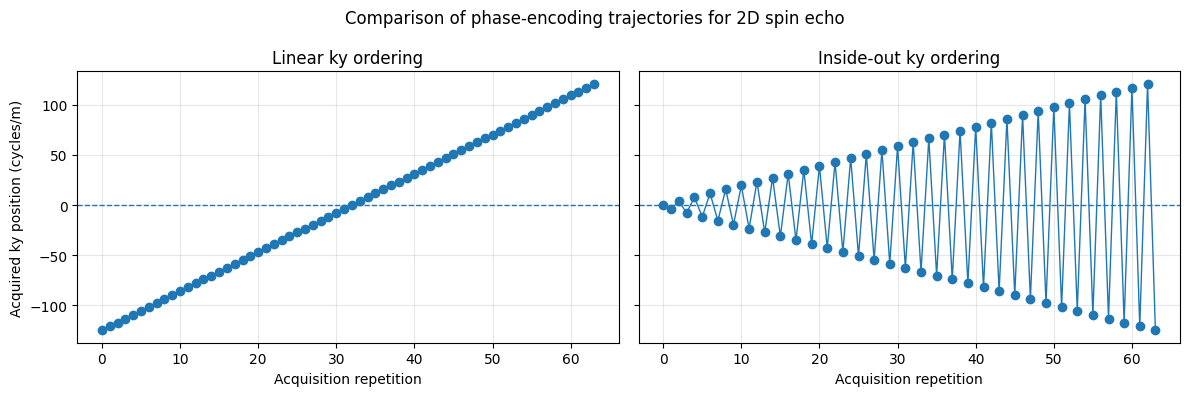

Interpretation:
- Linear ordering acquires ky lines from one side of k-space to the other.
- Inside-out ordering acquires central ky lines first, then alternates outward.
- For the first debug image, inside-out ordering is often more useful because
  low-spatial-frequency signal and gross image contrast appear early.


In [29]:
# Plot linear and inside-out phase-encoding trajectories

print("Compare phase-encoding trajectories")
print("-----------------------------------")

ky_linear = ky_grid[ky_order_linear]
ky_inside_out = ky_grid[ky_order_inside_out]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Linear ordering
axes[0].plot(np.arange(ny), ky_linear, marker="o", linewidth=1)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("Linear ky ordering")
axes[0].set_xlabel("Acquisition repetition")
axes[0].set_ylabel("Acquired ky position (cycles/m)")
axes[0].grid(True, alpha=0.3)

# Inside-out ordering
axes[1].plot(np.arange(ny), ky_inside_out, marker="o", linewidth=1)
axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_title("Inside-out ky ordering")
axes[1].set_xlabel("Acquisition repetition")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparison of phase-encoding trajectories for 2D spin echo")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Linear ordering acquires ky lines from one side of k-space to the other.")
print("- Inside-out ordering acquires central ky lines first, then alternates outward.")
print("- For the first debug image, inside-out ordering is often more useful because")
print("  low-spatial-frequency signal and gross image contrast appear early.")

In [30]:
# Build the main 2D spin echo sequence
#
# Sequence structure:
#
#   90x
#   gx_pre + gy_pre
#   delay to 180
#   180y
#   delay to TE
#   Gx readout + ADC
#   delay to TR
#
# This connects our prior steps:
#
# 1. RF SE:
#       90° pulse → 180° pulse → spin echo
#
# 2. 1D SE projection:
#       add Gx readout + ADC during the echo
#
# 3. 2D SE image:
#       add Gy phase encoding and repeat for many ky values
#
# Important spin-echo convention:
#   Gradients played before the 180° pulse are refocused with opposite sign.
#   Therefore:
#       gx_pre area = +kx_width/2
#   acts like starting readout at:
#       kx = -kx_width/2
#
#   Similarly, to achieve desired ky after the 180° pulse:
#       physical gy_pre area = -ky

print("Build main 2D spin echo sequence")
print("--------------------------------")

import numpy as np
import pypulseq as pp

# ----------------------------
# Scanner/system limits
# ----------------------------

system = pp.Opts(
    max_grad=10,
    grad_unit="mT/m",
    max_slew=50,
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
)

seq = pp.Sequence(system)


# ----------------------------
# RF events from RF SE notebook
# ----------------------------
# 90x: phase = 0
# 180y: phase = pi/2

rf90 = pp.make_block_pulse(
    flip_angle=np.pi / 2,
    duration=rf90_duration,
    phase_offset=0,
    delay=system.rf_dead_time,
    system=system,
)

rf180 = pp.make_block_pulse(
    flip_angle=np.pi,
    duration=rf180_duration,
    phase_offset=np.pi / 2,
    delay=system.rf_dead_time,
    system=system,
)

print("RF pulses created.")
print(f"  90° pulse width  : {rf90_duration*1e6:.1f} µs")
print(f"  180° pulse width : {rf180_duration*1e6:.1f} µs")
print("  RF phase order   : 90x, 180y")


# ----------------------------
# Readout event from 1D SE projection
# ----------------------------
# Gx readout samples kx during ADC.
# The flat_area sets the total kx width traversed during readout.
gx_pre = pp.make_trapezoid(
    channel="x",
    area=kx_width / 2,
    duration=prephaser_duration,
    system=system,
)

gx = pp.make_trapezoid(
    channel="x",
    flat_area=kx_width,
    flat_time=adc_duration,
    system=system,
)

adc = pp.make_adc(
    num_samples=nx,
    duration=adc_duration,
    delay=0,
    system=system,
)

print("\nReadout created.")
print(f"  Readout direction : x")
print(f"  ADC samples       : {nx}")
print(f"  ADC duration      : {adc_duration*1e3:.3f} ms")
print(f"  kx width          : {kx_width:.1f} cycles/m")


# ----------------------------
# Prephaser gradients before 180°
# ----------------------------
# These are played immediately after 90x and before 180y.
#
# Because they are before the 180° pulse, their effective contribution
# at the echo has opposite sign.
#
# Therefore:
#   physical gx_pre area = +kx_width/2
#   effective kx start   = -kx_width/2
#
# For phase encoding:
#   desired ky after refocusing = ky
#   physical gy_pre area        = -ky


print("\nReadout prephaser created.")
print(f"  physical gx_pre area  : {+kx_width/2:.1f} cycles/m")
print(f"  effective kx start    : {-kx_width/2:.1f} cycles/m")
print(f"  prephaser duration    : {prephaser_duration*1e3:.3f} ms")


# ----------------------------
# Phase encoding
# ----------------------------

print("\nPhase encoding.")
print(f"  Phase-encoding direction : y")
print(f"  Number of ky lines       : {ny}")
print(f"  Ordering                 : {phase_encode_ordering}")
print("  gy_pre is played before 180°, so physical area = -desired ky.")


# ----------------------------
# Timing delays
# ----------------------------
# TE is measured from center of 90° pulse to center of ADC.
#
# First half:
#   center 90° → gx_pre/gy_pre → delay_to_180 → center 180°
#
# Second half:
#   center 180° → delay_to_readout → center ADC

delay_to_180 = round_to_raster(
    TE / 2
    - rf90_duration / 2
    - prephaser_duration
    - rf180_duration / 2
)

delay_to_readout = round_to_raster(
    TE / 2
    - rf180_duration / 2
    - adc_duration / 2
)

if delay_to_180 < 0:
    raise ValueError(
        "delay_to_180 is negative. "
        "Increase TE or shorten the prephaser/RF durations."
    )

if delay_to_readout < 0:
    raise ValueError(
        "delay_to_readout is negative. "
        "Increase TE or shorten the ADC/RF durations."
    )

print("\nTiming.")
print(f"  Requested TE       : {TE*1e3:.3f} ms")
print(f"  Delay to 180       : {delay_to_180*1e3:.3f} ms")
print(f"  Delay to readout   : {delay_to_readout*1e3:.3f} ms")


# ----------------------------
# Build sequence line by line
# ----------------------------

metadata_2d = []

for line_idx, ky in enumerate(ky_values):

    # Desired ky after refocusing is ky.
    # Since this gradient is before 180°, use physical area = -ky.
    gy_pre = pp.make_trapezoid(
        channel="y",
        area=-ky,
        duration=prephaser_duration,
        system=system,
    )

    # 90x excitation
    seq.add_block(rf90)

    # Prephasers before 180:
    #   gx_pre prepares readout start
    #   gy_pre selects phase-encoding line
    seq.add_block(gx_pre, gy_pre)

    # Delay to center of 180° pulse
    seq.add_block(pp.make_delay(delay_to_180))

    # 180y refocusing pulse
    seq.add_block(rf180)

    # Delay so ADC center lands at TE
    seq.add_block(pp.make_delay(delay_to_readout))

    # Readout:
    #   Gx traverses kx while ADC samples the echo
    seq.add_block(gx, adc)

    # TR delay
    used_time = (
        rf90_duration
        + prephaser_duration
        + delay_to_180
        + rf180_duration
        + delay_to_readout
        + adc_duration
    )

    delay_to_TR = round_to_raster(TR - used_time)

    if delay_to_TR < 0:
        raise ValueError(
            f"TR is too short on line {line_idx}. "
            "Increase TR or shorten sequence timing."
        )

    seq.add_block(pp.make_delay(delay_to_TR))

    metadata_2d.append({
        "line_idx": line_idx,
        "ky_index": int(ky_order[line_idx]),
        "desired_ky_cycles_per_m": float(ky),
        "physical_gy_pre_area_cycles_per_m": float(-ky),
        "TE_ms": float(TE * 1e3),
        "TR_ms": float(TR * 1e3),
        "ordering": phase_encode_ordering,
    })


# ----------------------------
# Report summary
# ----------------------------

realized_TE = (
    rf90_duration / 2
    + prephaser_duration
    + delay_to_180
    + rf180_duration
    + delay_to_readout
    + adc_duration / 2
)

realized_TR = used_time + delay_to_TR

print("\n2D SE sequence constructed.")
print("---------------------------")
print(f"Number of k-space lines : {len(metadata_2d)}")
print(f"Matrix                  : {nx} × {ny}")
print(f"FOV                     : {fov_x_m*1e3:.1f} × {fov_y_m*1e3:.1f} mm")
print(f"Requested TE            : {TE*1e3:.3f} ms")
print(f"Realized TE             : {realized_TE*1e3:.3f} ms")
print(f"Requested TR            : {TR*1e3:.3f} ms")
print(f"Realized TR             : {realized_TR*1e3:.3f} ms")

print("\nFirst 8 acquired ky lines:")
for item in metadata_2d[:8]:
    print(
        f"  line {item['line_idx']:02d}: "
        f"ky index {item['ky_index']:02d}, "
        f"desired ky = {item['desired_ky_cycles_per_m']:8.1f} cycles/m, "
        f"physical gy_pre area = {item['physical_gy_pre_area_cycles_per_m']:8.1f} cycles/m"
    )

Build main 2D spin echo sequence
--------------------------------
RF pulses created.
  90° pulse width  : 150.0 µs
  180° pulse width : 300.0 µs
  RF phase order   : 90x, 180y

Readout created.
  Readout direction : x
  ADC samples       : 128
  ADC duration      : 8.000 ms
  kx width          : 500.0 cycles/m

Readout prephaser created.
  physical gx_pre area  : 250.0 cycles/m
  effective kx start    : -250.0 cycles/m
  prephaser duration    : 2.000 ms

Phase encoding.
  Phase-encoding direction : y
  Number of ky lines       : 64
  Ordering                 : linear
  gy_pre is played before 180°, so physical area = -desired ky.

Timing.
  Requested TE       : 20.000 ms
  Delay to 180       : 7.770 ms
  Delay to readout   : 5.850 ms

2D SE sequence constructed.
---------------------------
Number of k-space lines : 64
Matrix                  : 128 × 64
FOV                     : 256.0 × 256.0 mm
Requested TE            : 20.000 ms
Realized TE             : 19.995 ms
Requested TR        

Visualize 2D SE sequence timing
--------------------------------
Plotting first 64000.0 ms of the sequence.

Look for:
  1. 90° RF pulse
  2. delay to 180° RF pulse
  3. 180° RF pulse
  4. phase-encoding gradient on y
  5. readout gradient on x with ADC
  6. repetition for the next ky line


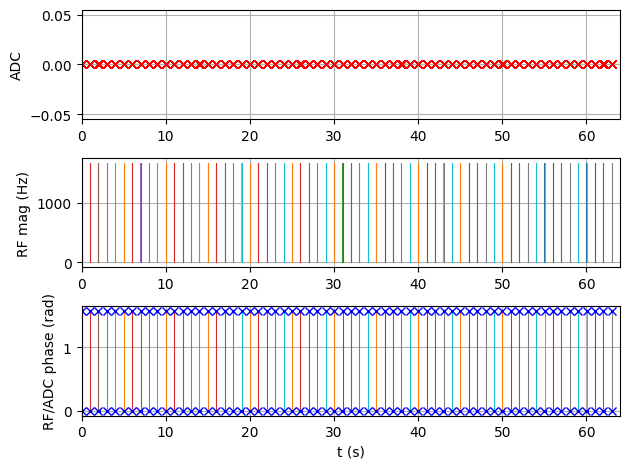

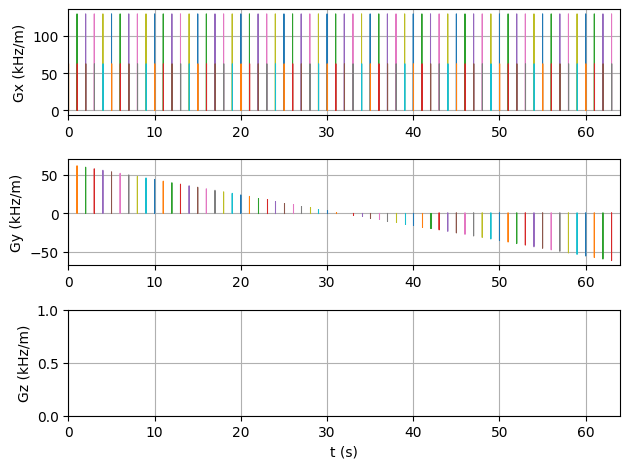

In [31]:
# Visualize the 2D spin echo sequence timing

print("Visualize 2D SE sequence timing")
print("--------------------------------")

# Plot the beginning of the sequence.
# The full sequence has ny TRs, so we only plot the first portion.

plot_window_s = min(64 * TR, 150 * TR)

print(f"Plotting first {plot_window_s*1e3:.1f} ms of the sequence.")
print()
print("Look for:")
print("  1. 90° RF pulse")
print("  2. delay to 180° RF pulse")
print("  3. 180° RF pulse")
print("  4. phase-encoding gradient on y")
print("  5. readout gradient on x with ADC")
print("  6. repetition for the next ky line")

seq.plot(time_range=(0, plot_window_s))

In [32]:
# Check timing and write the 2D SE sequence file

print("Check timing and write 2D SE sequence")
print("-------------------------------------")

ok, error_report = seq.check_timing()

if ok:
    print("PASS: Sequence timing check passed.")
else:
    print("WARNING: Sequence timing check failed.")
    for err in error_report:
        print(err)

# Only write the sequence if timing passes.
out_file = "se_2d_inside_out_02516T_FIXED.seq"

if ok:
    seq.write(out_file)
    print()
    print(f"PASS: Saved sequence file: {out_file}")
else:
    print()
    print("Sequence was not written because timing check failed.")

Check timing and write 2D SE sequence
-------------------------------------
PASS: Sequence timing check passed.

PASS: Saved sequence file: se_2d_inside_out_02516T_FIXED.seq


### Simulate the 2D SE sequence with MRZero

Now that we have created and exported the 2D spin echo `.seq` file, we will use MRZeroCore to simulate the sequence.

The goal is not to perfectly reproduce the scanner yet.

The goal is to connect the sequence-building workflow to image formation:

    PyPulseq sequence → .seq file → MRZero simulation → reconstructed image

For the simulation, we will use a simple human-brain-like digital object with:

- proton density map,
- T1 map,
- T2 map,
- B0 map,
- B1 map,
- receive coil sensitivity.

This lets us test whether the sequence can produce a reasonable 2D spin echo image before we run it on the scanner.

The same `.seq` file remains the scanner-facing output. MRZero is used here as a teaching and debugging tool.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import MRzeroCore as mr0
import brainweb_dl as bwdl

print("Load standardized BrainWeb anatomical phantom")
print("---------------------------------------------")

# ----------------------------
# 1. Load a BrainWeb anatomical image
# ----------------------------
# For teaching, use an anatomical contrast rather than fuzzy tissue maps.
# This gives a recognizable brain image.
#
# Good options to try:
#   contrast = "T1"
#   contrast = "T2"
#   contrast = "PD"
#
# We use T1 as the visual object and then convert it to a normalized
# proton-density-like map for simulation.

brainweb_contrast = "T1"

bw_img = bwdl.get_mri(
    sub_id=5,
    contrast=brainweb_contrast,
)

bw_img = np.asarray(bw_img, dtype=np.float32)

print("BrainWeb object type:", type(bw_img))
print("BrainWeb image shape:", bw_img.shape)
print("BrainWeb image dtype :", bw_img.dtype)
print("BrainWeb min/max     :", float(np.nanmin(bw_img)), float(np.nanmax(bw_img)))

if bw_img.ndim != 3:
    raise ValueError(
        f"Expected a 3D anatomical BrainWeb image, but got shape {bw_img.shape}."
    )


# ----------------------------
# 2. Inspect all three middle slices
# ----------------------------
# This helps us choose the best display/simulation plane.

mid_slices = [
    ("axis 0", bw_img.shape[0] // 2, bw_img[bw_img.shape[0] // 2, :, :]),
    ("axis 1", bw_img.shape[1] // 2, bw_img[:, bw_img.shape[1] // 2, :]),
    ("axis 2", bw_img.shape[2] // 2, bw_img[:, :, bw_img.shape[2] // 2]),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (axis_name, idx, img2d) in zip(axes, mid_slices):
    ax.imshow(img2d.T, origin="lower", cmap="gray")
    ax.set_title(f"{brainweb_contrast}: {axis_name}, slice {idx}")
    ax.axis("off")

plt.suptitle("Choose a BrainWeb slice orientation")
plt.tight_layout()
plt.show()


# ----------------------------
# 3. Choose the slice for the 2D SE simulation
# ----------------------------
# For many BrainWeb volumes, one of these will look more anatomical.
# Edit slice_axis if needed after viewing the montage above.
#
# slice_axis = 0, 1, or 2

slice_axis = 2
slice_idx = bw_img.shape[slice_axis] // 2

if slice_axis == 0:
    brain_2d_np = bw_img[slice_idx, :, :]
elif slice_axis == 1:
    brain_2d_np = bw_img[:, slice_idx, :]
elif slice_axis == 2:
    brain_2d_np = bw_img[:, :, slice_idx]
else:
    raise ValueError("slice_axis must be 0, 1, or 2.")

# Transpose for a more conventional display orientation.
brain_2d_np = brain_2d_np.T.astype(np.float32)

print("\nSelected BrainWeb slice.")
print(f"  Contrast   : {brainweb_contrast}")
print(f"  Slice axis : {slice_axis}")
print(f"  Slice index: {slice_idx}")
print(f"  2D shape   : {brain_2d_np.shape}")


# ----------------------------
# 4. Match object grid to notebook variables by resizing
# ----------------------------
# We resize the selected BrainWeb slice to [ny, nx].
#
# This keeps the full brain visible in the simulation object.
# For this workshop notebook, that is better pedagogically than cropping.
#
# Important:
#   This resized object is a standardized teaching phantom.
#   It is not intended to preserve exact BrainWeb physical voxel size.

from skimage.transform import resize

if "nx" not in globals():
    nx = 64

if "ny" not in globals():
    ny = 64

if "fov_x_m" not in globals():
    fov_x_m = 160e-3

if "fov_y_m" not in globals():
    fov_y_m = 160e-3

print("\nSimulation grid requested by notebook.")
print(f"  nx      : {nx}")
print(f"  ny      : {ny}")
print(f"  FOV x   : {fov_x_m*1e3:.1f} mm")
print(f"  FOV y   : {fov_y_m*1e3:.1f} mm")

print("\nResizing BrainWeb slice to match simulation matrix.")
print(f"  Original BrainWeb slice shape : {brain_2d_np.shape}")
print(f"  Resized simulation shape      : {(ny, nx)}")

brain_2d_np = resize(
    brain_2d_np,
    output_shape=(ny, nx),
    order=1,                 # bilinear interpolation
    mode="constant",
    cval=0.0,
    anti_aliasing=True,
    preserve_range=True,
).astype(np.float32)

# ----------------------------
# 5. Normalize image into a PD-like simulation map
# ----------------------------
# We want nonzero signal inside the brain and low signal outside.
# This is not a quantitative PD map; it is a clean standardized teaching object.

brain_2d_np = brain_2d_np - np.nanmin(brain_2d_np)

if np.nanmax(brain_2d_np) > 0:
    brain_2d_np = brain_2d_np / np.nanmax(brain_2d_np)

# Suppress very low background.
brain_2d_np[brain_2d_np < 0.05] = 0.0

PD_2d_np = brain_2d_np.astype(np.float32)

# Simple constant tissue properties for first 2D SE simulation.
# These keep the focus on sequence geometry and k-space, not tissue modeling.
T1_2d_np = np.where(PD_2d_np > 0, 1.0, 0.0).astype(np.float32)
T2_2d_np = np.where(PD_2d_np > 0, 0.080, 0.0).astype(np.float32)

PD_2d = torch.tensor(PD_2d_np, dtype=torch.float32)
T1_2d = torch.tensor(T1_2d_np, dtype=torch.float32)
T2_2d = torch.tensor(T2_2d_np, dtype=torch.float32)


# ----------------------------
# 6. Define spatial coordinates in meters
# ----------------------------
# Image arrays are [ny, nx].
# Therefore X and Y must also be [ny, nx].
#
# x runs across columns.
# y runs across rows.

x = torch.linspace(
    -fov_x_m / 2,
    fov_x_m / 2,
    nx,
    dtype=torch.float32,
)

y = torch.linspace(
    -fov_y_m / 2,
    fov_y_m / 2,
    ny,
    dtype=torch.float32,
)

Y, X = torch.meshgrid(y, x, indexing="ij")

print("\nCoordinate grid.")
print(f"  X shape : {tuple(X.shape)}")
print(f"  Y shape : {tuple(Y.shape)}")
print(f"  PD shape: {tuple(PD_2d.shape)}")


# ----------------------------
# 7. Mask background voxels for faster MRZero simulation
# ----------------------------

mask = PD_2d > 0.05

flat_PD = PD_2d[mask]
flat_T1 = T1_2d[mask]
flat_T2 = T2_2d[mask]

flat_x = X[mask]
flat_y = Y[mask]
flat_z = torch.zeros_like(flat_x)

flat_pos = torch.stack([flat_x, flat_y, flat_z], dim=-1)

print("\nMasked BrainWeb phantom.")
print(f"  Number of active spins : {flat_PD.numel()}")
print(f"  Fraction retained      : {flat_PD.numel() / PD_2d.numel():.3f}")


# ----------------------------
# 8. Package into MRZero CustomVoxelPhantom
# ----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

zeros = torch.zeros_like(flat_PD)
ones = torch.ones_like(flat_PD)

phantom = mr0.CustomVoxelPhantom(
    pos=flat_pos.to(device),
    PD=flat_PD.to(device),
    T1=flat_T1.to(device),
    T2=flat_T2.to(device),
    T2dash=(30e-3 * ones).to(device),
    D=zeros.to(device),
    B0=zeros.to(device),
    B1=ones.to(device),
    voxel_size=float(min(fov_x_m / nx, fov_y_m / ny)),
    voxel_shape="box",
)

print("\nMRZero CustomVoxelPhantom created.")
print(f"  Device        : {device}")
print(f"  Active spins  : {flat_PD.numel()}")
print(f"  Voxel size    : {min(fov_x_m / nx, fov_y_m / ny)*1e3:.3f} mm")

sim_data = phantom.build()

print("\nMRZero simulation data built.")
print("  sim_data type:", type(sim_data))


# ----------------------------
# 9. Visualize simulation object
# ----------------------------

plt.figure(figsize=(5, 5))
plt.imshow(PD_2d.cpu().numpy(), origin="lower", cmap="gray")
plt.title("BrainWeb anatomical simulation object")
plt.axis("off")
plt.colorbar(label="Normalized signal / PD-like weight")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(mask.cpu().numpy(), origin="lower", cmap="gray")
plt.title("Active spin mask used for MRZero simulation")
plt.axis("off")
plt.show()

In [ ]:
# Load the generated .seq file, run MRZero simulation, and reconstruct Cartesian data

print("Load .seq file, run MRZero simulation, and reconstruct")
print("------------------------------------------------------")

import numpy as np
import matplotlib.pyplot as plt
import torch
import MRzeroCore as mr0
from pathlib import Path

seq_file = Path(out_file)

print("Sequence file:", seq_file)
print("Exists       :", seq_file.exists())

if not seq_file.exists():
    raise FileNotFoundError(f"Could not find sequence file: {seq_file}")


# ------------------------------------------------------------
# Load sequence into MRZero
# ------------------------------------------------------------

mr0_seq = mr0.Sequence.import_file(str(seq_file))

print("\nPASS: MRZero loaded the .seq file.")
print("MRZero sequence type:", type(mr0_seq))


# ------------------------------------------------------------
# Run simulation
# ------------------------------------------------------------

print("\nComputing MRZero graph...")

graph = mr0.compute_graph(
    mr0_seq,
    sim_data,
    max_state_count=200,
    min_state_mag=1e-4,
)

print("Executing MRZero graph...")

signal = mr0.execute_graph(
    graph,
    mr0_seq,
    sim_data,
    print_progress=True,
)

print("\nPASS: MRZero simulation completed.")
print("Raw signal type :", type(signal))

if hasattr(signal, "shape"):
    print("Raw signal shape:", tuple(signal.shape))


# ------------------------------------------------------------
# Convert MRZero signal to a 1D complex NumPy vector
# ------------------------------------------------------------

def signal_to_complex_vector(signal):
    """
    Convert MRZero signal output to a 1D complex NumPy vector.

    Handles common cases:
    - complex torch tensor
    - real tensor with last dimension = 2 for real/imag
    - tensor with a receive-coil dimension
    """

    if isinstance(signal, torch.Tensor):
        arr = signal.detach().cpu().numpy()
    else:
        arr = np.asarray(signal)

    print("\nSignal conversion")
    print("-----------------")
    print("Input array shape:", arr.shape)
    print("Input dtype      :", arr.dtype)

    # Case 1: already complex
    if np.iscomplexobj(arr):
        # If there is a coil dimension, use the first coil for this tutorial.
        if arr.ndim == 2 and arr.shape[1] <= 8:
            print("Interpreting second dimension as coil/channel dimension.")
            arr = arr[:, 0]

        return np.asarray(arr).reshape(-1)

    # Case 2: last dimension stores real/imag
    if arr.ndim >= 2 and arr.shape[-1] == 2:
        print("Interpreting last dimension as real/imag.")
        arr_complex = arr[..., 0] + 1j * arr[..., 1]
        return np.asarray(arr_complex).reshape(-1)

    # Case 3: real-valued signal with possible channel dimension
    if arr.ndim == 2 and arr.shape[1] <= 8:
        print("Interpreting second dimension as coil/channel dimension; using channel 0.")
        arr = arr[:, 0]

    return np.asarray(arr, dtype=np.complex64).reshape(-1)


signal_vec = signal_to_complex_vector(signal)

print("Complex signal vector length:", signal_vec.size)


# ------------------------------------------------------------
# Infer samples per ky line
# ------------------------------------------------------------

if signal_vec.size % ny != 0:
    raise ValueError(
        f"Signal length {signal_vec.size} is not divisible by ny={ny}. "
        "We need to inspect how MRZero packed the ADC samples."
    )

n_ro_sim = signal_vec.size // ny

print("\nData layout")
print("-----------")
print(f"Expected ny lines              : {ny}")
print(f"Expected readout samples nx    : {nx}")
print(f"MRZero samples per ky line     : {n_ro_sim}")

if n_ro_sim != nx:
    print()
    print("NOTE: MRZero returned a different number of readout samples than nx.")
    print("For this tutorial reconstruction, we will use the returned sample count.")
    print("This avoids padding zeros into k-space.")


# ------------------------------------------------------------
# Reshape into acquisition order
# ------------------------------------------------------------

kspace_acq_order = signal_vec.reshape(ny, n_ro_sim)

print("\nK-space arrays")
print("--------------")
print("kspace_acq_order shape:", kspace_acq_order.shape)


# ------------------------------------------------------------
# Reorder ky lines from inside-out acquisition order to Cartesian grid order
# ------------------------------------------------------------

kspace_cartesian = np.zeros_like(kspace_acq_order, dtype=np.complex64)

for acq_rep, ky_index in enumerate(ky_order):
    kspace_cartesian[ky_index, :] = kspace_acq_order[acq_rep, :]

print("kspace_cartesian shape:", kspace_cartesian.shape)


# ------------------------------------------------------------
# Display acquired and reordered k-space
# ------------------------------------------------------------

plt.figure(figsize=(5, 5))
plt.imshow(
    np.log1p(np.abs(kspace_acq_order)),
    origin="lower",
    aspect="auto",
)
plt.title("MRZero k-space as acquired\ninside-out ky order")
plt.xlabel("kx sample")
plt.ylabel("Acquisition repetition")
plt.colorbar(label="log(1 + |signal|)")
plt.show()

plt.figure(figsize=(5, 5))
plt.imshow(
    np.log1p(np.abs(kspace_cartesian)),
    origin="lower",
    aspect="auto",
)
plt.title("Reordered Cartesian k-space\nky grid order restored")
plt.xlabel("kx sample")
plt.ylabel("ky grid index")
plt.colorbar(label="log(1 + |k-space|)")
plt.show()


# Reconstruct using several FFT convention checks

print("FFT reconstruction convention check")
print("-----------------------------------")

# kspace_cartesian should already be:
#   rows    = ky grid order restored
#   columns = kx readout samples
#
# However, FFT conventions can differ:
#   - Is DC at the center of the array?
#   - Is DC at index 0?
#   - Is readout reversed?
#   - Do we need image-domain fftshift for display?

def normalize_image(img):
    """Normalize magnitude image for display."""
    img = np.abs(img)
    if np.max(img) > 0:
        img = img / np.max(img)
    return img




# Most common MRI convention:



# If MRZero already gives k-space in FFT order.
img = np.abs(normalize_image(
        np.fft.fftshift(np.fft.ifft2(kspace_cartesian)))
    )

plt.figure(figsize=(5, 5))
plt.imshow(
    img,
    origin="lower",
    aspect="auto",
    cmap="gray"
)
plt.title("MRZero reconstruction: ifft2(kspace_cartesian)")
plt.show()



print("\nReconstruction complete.")
print("------------------------")
print("If one image is mirrored but recognizable, that is only a readout-direction convention.")
print("If the object is still not recognizable, the next debug target is the ADC/readout timing.")